# Deepfake Detection Dataset 2026: EDA

Use this notebook to inspect the Kaggle metadata, validate label and split distributions, and generate lightweight exploratory plots.

Run the Kaggle download first if `data/raw/FINAL_DATASET.csv` is missing:

```powershell
python scripts/download_kaggle_dataset.py
```

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from deepfake_detection.config import load_config, resolve_path
from deepfake_detection.data import normalize_splits, read_metadata

config = load_config(PROJECT_ROOT / "configs/default.yaml")
dataset_cfg = config["dataset"]
reports_dir = resolve_path(config["reports"]["output_dir"])
reports_dir.mkdir(parents=True, exist_ok=True)
config

{'dataset': {'kaggle_slug': 'chuneeb/deepfake-detection-dataset-2026',
  'raw_dir': 'data/raw',
  'csv_path': 'data/raw/FINAL_DATASET.csv',
  'images_dir': 'data/processed/images',
  'metadata_path': 'data/processed/metadata_with_paths.csv',
  'split_column': 'split',
  'label_column': 'label_numeric',
  'url_column': 'image_url',
  'id_column': 'image_id'},
 'download': {'timeout_seconds': 20,
  'max_workers': 16,
  'image_size': 224,
  'limit': None},
 'training': {'seed': 42,
  'batch_size': 32,
  'epochs': 5,
  'learning_rate': 0.0003,
  'num_workers': 2,
  'pretrained': True,
  'device': 'auto',
  'output_dir': 'models',
  'best_model_name': 'best_resnet18.pt'},
 'reports': {'output_dir': 'reports'}}

In [2]:
df = read_metadata(dataset_cfg["csv_path"])
df = normalize_splits(
    df,
    label_column=dataset_cfg["label_column"],
    split_column=dataset_cfg["split_column"],
    seed=config["training"]["seed"],
)

print(df.shape)
df.head()

(6557, 18)


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,resolution,confidence_score,detection_difficulty,dataset_split,date_collected,version,year,split
0,1,https://images.unsplash.com/photo-172422561835...,REAL,1,Authentic,Female,18-25,Unsplash,NaN,High,1080x1080,0.96,Easy,train,2026-04-24,v2.0,2026,train
1,2,https://images.unsplash.com/photo-172422561873...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,1080x1080,0.97,Easy,train,2026-04-04,v2.0,2026,train
2,3,https://images.unsplash.com/photo-172422561834...,REAL,1,Authentic,Female,36-50,Unsplash,NaN,High,1080x1080,0.95,Easy,test,2026-02-07,v2.0,2026,test
3,4,https://images.unsplash.com/photo-172422561855...,REAL,1,Authentic,Female,26-35,Unsplash,NaN,High,1080x1080,0.89,Easy,train,2026-02-20,v2.0,2026,train
4,5,https://images.unsplash.com/photo-172422561823...,REAL,1,Authentic,Male,36-50,Unsplash,NaN,High,1080x1080,0.86,Easy,train,2026-04-12,v2.0,2026,train


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6557 entries, 0 to 6556
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image_id              6557 non-null   int64  
 1   image_url             6557 non-null   str    
 2   label                 6557 non-null   str    
 3   label_numeric         6557 non-null   int64  
 4   category              6557 non-null   str    
 5   gender                6557 non-null   str    
 6   age_group             6557 non-null   str    
 7   source                6557 non-null   str    
 8   fake_method           3767 non-null   str    
 9   image_quality         6557 non-null   str    
 10  resolution            6557 non-null   str    
 11  confidence_score      6557 non-null   float64
 12  detection_difficulty  6557 non-null   str    
 13  dataset_split         6557 non-null   str    
 14  date_collected        6557 non-null   str    
 15  version               6557 non-n

In [4]:
summary_columns = [
    "label",
    dataset_cfg["label_column"],
    dataset_cfg["split_column"],
    "gender",
    "age_group",
    "image_quality",
    "source",
    "fake_method",
    "detection_difficulty",
]

for column in summary_columns:
    if column in df.columns:
        display(df[column].value_counts(dropna=False).rename_axis(column).to_frame("count"))

,count
label,
FAKE,3767
REAL,2790


,count
label_numeric,
0,3767
1,2790


,count
split,
train,4589
test,1312
val,656


,count
gender,
Unknown,4507
Female,1033
Male,1017


,count
age_group,
18-25,1681
36-50,1670
26-35,1650
50+,1556


,count
image_quality,
High,4350
Medium,2207


,count
source,
MultiSource,3767
Unsplash,2790


,count
fake_method,
StyleGAN3,3767
NaN,2790


,count
detection_difficulty,
Easy,2790
Hard,2461
Medium,1306


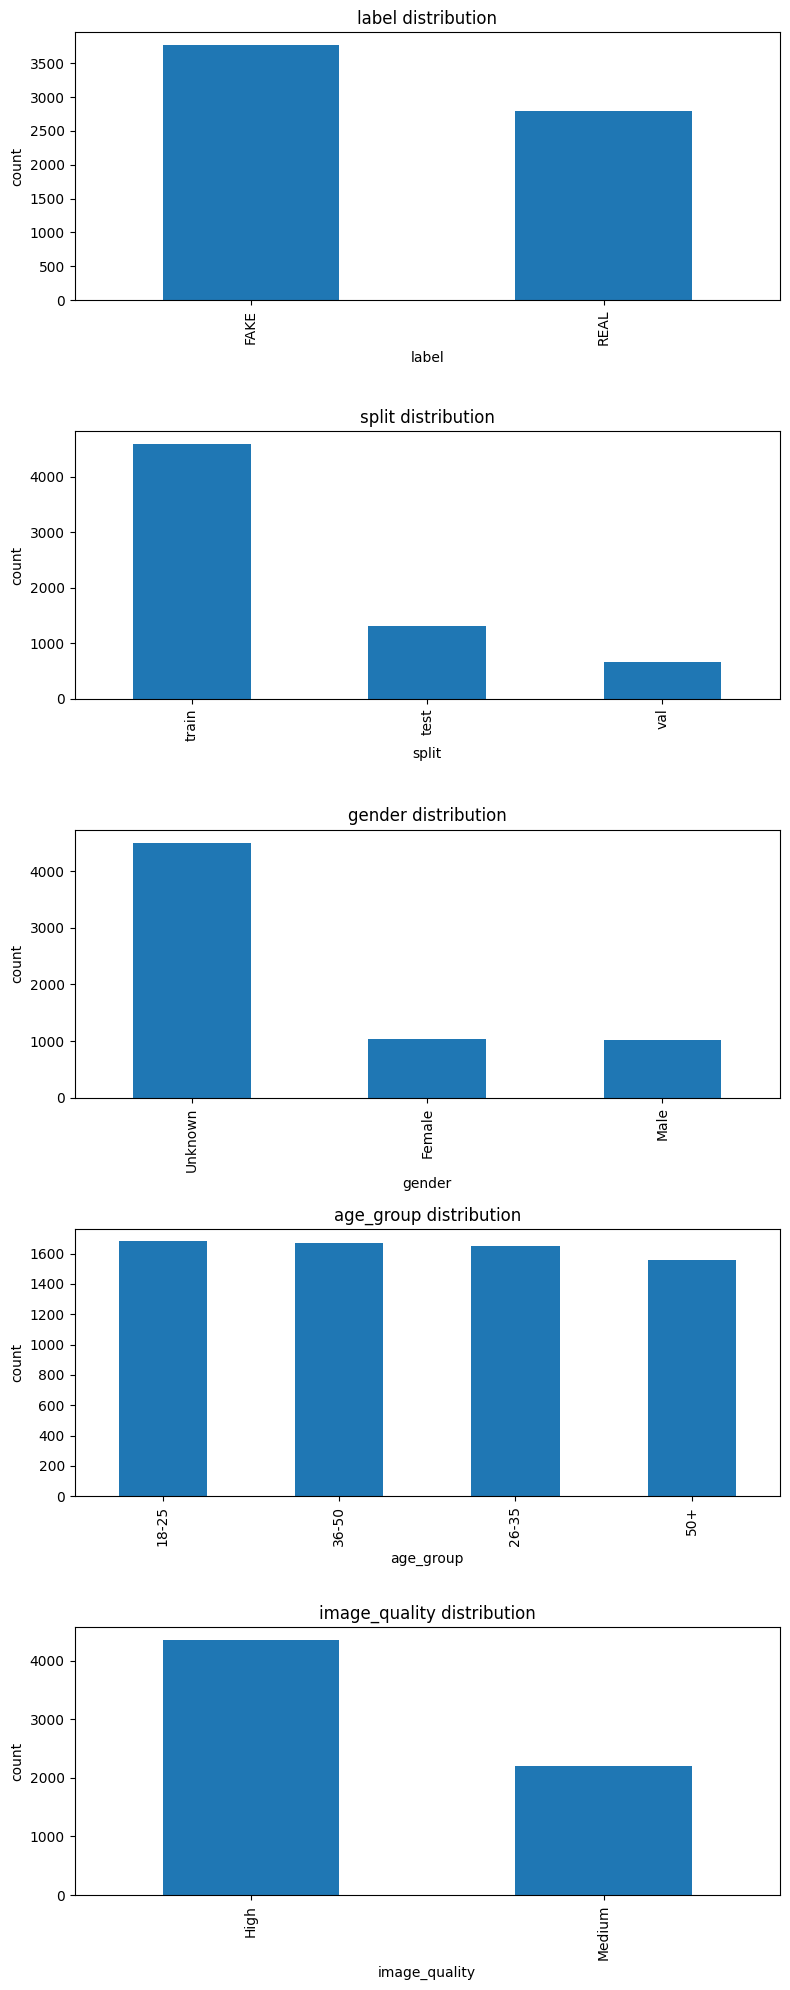

In [5]:
import matplotlib.pyplot as plt

plot_columns = ["label", dataset_cfg["split_column"], "gender", "age_group", "image_quality"]
fig, axes = plt.subplots(len(plot_columns), 1, figsize=(8, 4 * len(plot_columns)))

for ax, column in zip(axes, plot_columns):
    if column in df.columns:
        df[column].value_counts(dropna=False).plot(kind="bar", ax=ax, title=f"{column} distribution")
        ax.set_xlabel(column)
        ax.set_ylabel("count")

plt.tight_layout()

label,FAKE,REAL
split,,
test,754,558
train,2636,1953
val,377,279


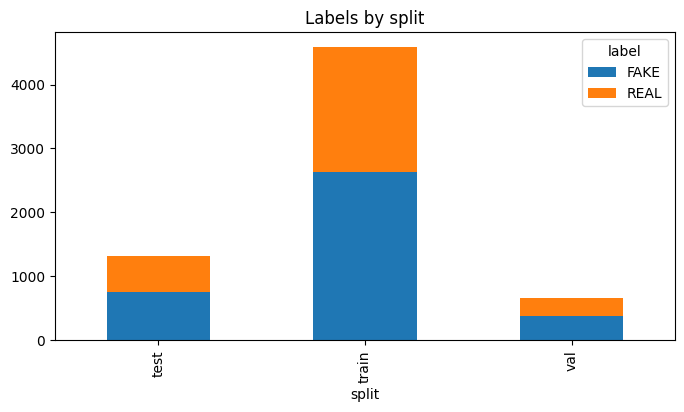

In [6]:
if {"label", dataset_cfg["split_column"]}.issubset(df.columns):
    split_label_counts = df.groupby([dataset_cfg["split_column"], "label"]).size().unstack(fill_value=0)
    display(split_label_counts)
    split_label_counts.plot(kind="bar", stacked=True, figsize=(8, 4), title="Labels by split")

In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

fake_method    2790
dtype: int64

In [8]:
from deepfake_detection.eda import run_eda

summary = run_eda(PROJECT_ROOT / "configs/default.yaml")
summary

Saved EDA outputs to C:\Users\akhil\OneDrive\Documents\ML Kaggle DS Projects\deepfake-detection-dataset-2026\reports


{'rows': 6557,
 'columns': ['image_id',
  'image_url',
  'label',
  'label_numeric',
  'category',
  'gender',
  'age_group',
  'source',
  'fake_method',
  'image_quality',
  'resolution',
  'confidence_score',
  'detection_difficulty',
  'dataset_split',
  'date_collected',
  'version',
  'year',
  'split'],
 'labels': {'FAKE': 3767, 'REAL': 2790},
 'label_numeric': {'0': 3767, '1': 2790},
 'splits': {'train': 4589, 'test': 1312, 'val': 656},
 'gender': {'Unknown': 4507, 'Female': 1033, 'Male': 1017},
 'age_group': {'18-25': 1681, '36-50': 1670, '26-35': 1650, '50+': 1556},
 'image_quality': {'High': 4350, 'Medium': 2207},
 'source': {'MultiSource': 3767, 'Unsplash': 2790},
 'fake_method': {'StyleGAN3': 3767, 'nan': 2790}}